# Kalman Filter Assignment

# Q. Analytical Derivation

## Setup

Given
$$
x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \qquad
y^{-}_k = H_k\,x^{-}_k + z_k,
$$
with
$$
x^{+}_{k-1}\sim \mathscr N(m_{k-1},P_{k-1}),\qquad
w_{k-1}\sim\mathscr N(0,\Sigma_p),\qquad z_k\sim\mathscr N(0,\Sigma_m),
$$
and $x^{+}_{k-1}$, $w_{k-1}$, $z_k$ mutually independent. We repeatedly use the fact that **any affine function of jointly Gaussian random vectors is Gaussian**, and that for jointly Gaussian (or independent) vectors a stacked vector is Gaussian iff each component is an affine function of a common set of independent Gaussians.

## Part 1

Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent Gaussian vectors, the stacked vector
$\begin{bmatrix}x^{+}_{k-1}\\ w_{k-1}\end{bmatrix}$ is jointly Gaussian. Because
$$
x_k^- = \begin{bmatrix}A_{k-1} & G_{k-1}\end{bmatrix}\begin{bmatrix}x^{+}_{k-1}\\ w_{k-1}\end{bmatrix}
$$
is a linear function of a Gaussian vector, $x_k^-$ is Gaussian. Its mean and covariance follow from linearity of expectation and the bilinearity of covariance:

**Mean.**
$$
\mathbb E[x_k^-] = A_{k-1}\,\mathbb E[x^{+}_{k-1}] + G_{k-1}\,\mathbb E[w_{k-1}] = A_{k-1}m_{k-1} + G_{k-1}\cdot 0 = A_{k-1}m_{k-1} \triangleq m_k^-.
$$

**Covariance.** Using independence of $x^+_{k-1}$ and $w_{k-1}$ (so the cross-covariance terms vanish):
$$
\operatorname{Cov}(x_k^-) = A_{k-1}\operatorname{Cov}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\operatorname{Cov}(w_{k-1})G_{k-1}^T
= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T \triangleq P_k^-.
$$

Hence $x_k^- \sim \mathscr N(m_k^-,P_k^-)$ as claimed. $\blacksquare$

## Part 2

From Part 1, $x_k^-\sim\mathscr N(m_k^-,P_k^-)$, and $z_k\sim\mathscr N(0,\Sigma_m)$ is independent of $x_k^-$ (since $z_k$ is independent of $x^+_{k-1}$ and $w_{k-1}$). The vector
$$
y_k^- = \begin{bmatrix}H_k & I\end{bmatrix}\begin{bmatrix}x_k^-\\ z_k\end{bmatrix}
$$
is an affine function of jointly Gaussian (here, independent) vectors, hence Gaussian.

**Mean.**
$$
\mathbb E[y_k^-] = H_k m_k^- + 0 = H_k m_k^-.
$$

**Covariance.**
$$
\operatorname{Cov}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m.
$$

Hence $y_k^- \sim \mathscr N\!\big(H_k m_k^-,\ H_k P_k^- H_k^T+\Sigma_m\big)$. $\blacksquare$

## Part 3

Write the stacked vector as a linear map of the independent Gaussian vectors $x_k^-$ and $z_k$:
$$
\begin{bmatrix}x_k^-\\ y_k^-\end{bmatrix}
=\begin{bmatrix}I & 0\\ H_k & I\end{bmatrix}\begin{bmatrix}x_k^-\\ z_k\end{bmatrix}.
$$
A linear transformation of a Gaussian vector is Gaussian, so $(x_k^-,y_k^-)$ is jointly Gaussian. The mean is obtained by stacking the means from Parts 1 and 2:
$$
\mathbb E\begin{bmatrix}x_k^-\\ y_k^-\end{bmatrix}=\begin{bmatrix}m_k^-\\ H_k m_k^-\end{bmatrix}.
$$

For the covariance blocks, use independence of $x_k^-$ and $z_k$:

* $\operatorname{Cov}(x_k^-,x_k^-) = P_k^-$.
* $\operatorname{Cov}(x_k^-,y_k^-) = \operatorname{Cov}\big(x_k^-,\,H_k x_k^- + z_k\big) = \operatorname{Cov}(x_k^-)H_k^T = P_k^- H_k^T$.
* $\operatorname{Cov}(y_k^-,x_k^-) = \big(P_k^- H_k^T\big)^T = H_k P_k^-$.
* $\operatorname{Cov}(y_k^-,y_k^-) = H_k P_k^- H_k^T + \Sigma_m$ (Part 2).

Assembling these blocks gives
$$
\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\!\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right). \qquad \blacksquare
$$

## Part 4

**Lemma (Gaussian conditioning).** If
$$
\begin{bmatrix}a\\ b\end{bmatrix}\sim\mathscr N\!\left(\begin{bmatrix}\mu_a\\ \mu_b\end{bmatrix},\begin{bmatrix}\Sigma_{aa} & \Sigma_{ab}\\ \Sigma_{ba} & \Sigma_{bb}\end{bmatrix}\right),
$$
with $\Sigma_{bb}$ invertible, then
$$
(a\mid b=b_0)\sim \mathscr N\big(\mu_a+\Sigma_{ab}\Sigma_{bb}^{-1}(b_0-\mu_b),\ \ \Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}\big).
$$
*Sketch of proof:* complete the square in the joint Gaussian density $p(a,b)\propto \exp\{-\tfrac12 (z-\mu)^T\Sigma^{-1}(z-\mu)\}$, $z=(a,b)$, using the block-matrix (Schur complement) inverse
$$
\Sigma^{-1}=\begin{bmatrix}\Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba} & \star\\ \star & \star\end{bmatrix}^{-1}\!\!\!,
$$
and observe that conditioning on $b=b_0$ in a joint Gaussian removes the dependence on $b$ from the normalizing constant, leaving a quadratic form in $a$ alone whose mean and covariance are exactly the expressions above.

**Application.** Set $a=x_k^-,\ b=y_k^-$. From Part 3,
$$
\mu_a=m_k^-,\quad \mu_b=H_km_k^-,\quad \Sigma_{aa}=P_k^-,\quad \Sigma_{ab}=P_k^-H_k^T,\quad \Sigma_{bb}=H_kP_k^-H_k^T+\Sigma_m \triangleq S_k.
$$
Define
$$
K_k \triangleq \Sigma_{ab}\Sigma_{bb}^{-1} = P_k^- H_k^T S_k^{-1} = P_k^-H_k^T\big(H_kP_k^-H_k^T+\Sigma_m\big)^{-1}.
$$
Then, by the lemma,
$$
m_k = m_k^- + K_k\big(y_k^{\mathrm{obs}} - H_k m_k^-\big),
$$
$$
P_k = \Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba} = P_k^- - K_k H_k P_k^- = (I-K_kH_k)P_k^-.
$$
Hence $x_k^+ = (x_k^-\mid y_k^-=y_k^{\mathrm{obs}}) \sim \mathscr N(m_k,P_k)$. $\blacksquare$

## Part 5

These were derived in Part 4 above, by definition of $m_k,P_k$ as the parameters of the conditional law:
$$
\mathbb E\big[x_k^- \mid y_k^- = y_k^{\mathrm{obs}}\big] = m_k = m_k^- + K_k\big(y_k^{\mathrm{obs}}-H_km_k^-\big),
$$
$$
\operatorname{Var}\big(x_k^- \mid y_k^- = y_k^{\mathrm{obs}}\big) = P_k = (I-K_kH_k)P_k^-,
$$
with $K_k = P_k^-H_k^T(H_kP_k^-H_k^T+\Sigma_m)^{-1}$ the Kalman gain. This is exactly the recursive **predict\u2013update** pair that defines the Kalman filter: Part 1 is the *predict* step, and Parts 3\u20134 give the *update* (correction) step.

# Q. 1-D Example

## Parts 1 - 4

The scalar model
$$
x^-_k = a\,x^+_{k-1} + w_{k-1},\ w_{k-1}\sim\mathscr N(0,q),\qquad
y^-_k = h\,x^-_k + z_k,\ z_k\sim\mathscr N(0,r),
$$
is the special case of the general (vector) model with $A_{k-1}=a$, $G_{k-1}=1$, $\Sigma_p=q$, $H_k=h$, $\Sigma_m=r$ (all $1\times1$ "matrices"). Every result below is therefore a direct specialization of the corresponding part of the **Analytical Derivation** question.

**1. Prediction.** From Part 1 above (with $A=a,\,G=1,\,\Sigma_p=q$):
$$
m_k^- = a\,m_{k-1}, \qquad P_k^- = a^2P_{k-1} + q.
$$

**2. Update.** From Part 4 above (with $H=h,\,\Sigma_m=r$), the Kalman gain is
$$
K_k = \frac{P_k^- h}{h^2P_k^- + r} = \frac{P_k^- h}{S_k},\qquad S_k \triangleq h^2P_k^- + r,
$$
and, with the innovation $v_k \triangleq y_k^{\mathrm{obs}} - h\,m_k^-$,
$$
m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k}\big(y_k^{\mathrm{obs}} - h\,m_k^-\big),
$$
$$
P_k = (1-K_kh)\,P_k^- = \Big(1-\frac{P_k^-h^2}{S_k}\Big)P_k^-.
$$

**3. Predictive measurement distribution (prior to seeing $y_k$).** This is exactly Part 2 of the Analytical Derivation, applied at time $k$ using only information up to $k-1$ (i.e. conditioned on $Y_{k-1}$, which determines $m_{k-1},P_{k-1}$ and hence $m_k^-,P_k^-$ via Part 1):
$$
p(y_k^- \mid Y_{k-1}) = \mathscr N\big(h\,m_k^-,\ h^2P_k^- + r\big).
$$

**4. Posterior-predictive measurement distribution (after filtering on $y_k$).** Once $y_k^{\mathrm{obs}}$ has been incorporated, the state law updates to $x_k^+\sim\mathscr N(m_k,P_k)$ (Part 4 above). Applying the *measurement equation* $y_k^- = h\,x_k^- + z_k$ once more, but now with $x_k^- $ replaced by the **updated** state $x_k^+\sim\mathscr N(m_k,P_k)$ (i.e. evaluating the same affine-Gaussian argument as in Part 2, conditioned on $Y_k$), gives
$$
p(y_k^- \mid Y_k) = \mathscr N\big(h\,m_k,\ h^2P_k + r\big).
$$
Intuitively: before seeing $y_k$ we predict the measurement using the *prior* (predicted) state law $(m_k^-,P_k^-)$; after seeing $y_k$ we can re-evaluate "what does the model now say the measurement should look like" using the *posterior* (filtered) state law $(m_k,P_k)$ \u2014 and since $P_k\le P_k^-$ (information has been gained), the posterior-predictive measurement distribution is tighter than the prior-predictive one.

## Part 5

We pick
$$
a=0.95,\quad q=0.05,\quad h=1.0,\quad r=0.3,\quad m_0=0,\quad P_0=1,
$$
simulate a true latent trajectory and noisy measurements, run the scalar Kalman filter, and animate, at each time step $k$, the **prior** $\mathscr N(m_k^-,P_k^-)$ and the **posterior** $\mathscr N(m_k,P_k)$ density over $x$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

rng = np.random.default_rng(0)

# ---- model parameters ----
a, q, h, r = 0.95, 0.05, 1.0, 0.3
m0, P0 = 0.0, 1.0
N = 40

# ---- simulate the true latent state and noisy measurements ----
x_true = np.zeros(N)
y_obs  = np.zeros(N)
x_prev = m0
for k in range(N):
    w = rng.normal(0, np.sqrt(q))
    x_true[k] = a * x_prev + w
    z = rng.normal(0, np.sqrt(r))
    y_obs[k] = h * x_true[k] + z
    x_prev = x_true[k]

# ---- scalar Kalman filter ----
m_pred = np.zeros(N); P_pred = np.zeros(N)
m_filt = np.zeros(N); P_filt = np.zeros(N)
m_prev, P_prev = m0, P0
for k in range(N):
    # predict
    m_minus = a * m_prev
    P_minus = a**2 * P_prev + q
    # update
    S = h**2 * P_minus + r
    K = P_minus * h / S
    v = y_obs[k] - h * m_minus
    m_k = m_minus + K * v
    P_k = (1 - K * h) * P_minus

    m_pred[k], P_pred[k] = m_minus, P_minus
    m_filt[k], P_filt[k] = m_k, P_k
    m_prev, P_prev = m_k, P_k

print("Filter ran for", N, "steps.")
print("Final filtered mean / variance:", m_filt[-1], P_filt[-1])


Filter ran for 40 steps.
Final filtered mean / variance: 1.0920825043573499 0.09228603058709114


In [2]:
# ---- animation of prior (predicted) vs posterior (filtered) density at each step ----
xs = np.linspace(min(x_true.min(), y_obs.min()) - 2, max(x_true.max(), y_obs.max()) + 2, 400)

fig, ax = plt.subplots(figsize=(7, 4.5))
line_prior, = ax.plot([], [], lw=2, color="tab:blue", label="prior $\\mathcal{N}(m_k^-,P_k^-)$")
line_post,  = ax.plot([], [], lw=2, color="tab:red",  label="posterior $\\mathcal{N}(m_k,P_k)$")
true_marker = ax.axvline(x_true[0], color="k", ls="--", lw=1, label="true $x_k$")
obs_marker  = ax.axvline(y_obs[0], color="tab:green", ls=":", lw=1.5, label="observation $y_k^{obs}$")
ax.set_xlim(xs.min(), xs.max())
ax.set_ylim(0, 3.0)
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend(loc="upper right", fontsize=9)
title = ax.set_title("")

def init():
    line_prior.set_data([], [])
    line_post.set_data([], [])
    return line_prior, line_post, true_marker, obs_marker, title

def update(k):
    prior_pdf = norm.pdf(xs, loc=m_pred[k], scale=np.sqrt(P_pred[k]))
    post_pdf  = norm.pdf(xs, loc=m_filt[k], scale=np.sqrt(P_filt[k]))
    line_prior.set_data(xs, prior_pdf)
    line_post.set_data(xs, post_pdf)
    true_marker.set_xdata([x_true[k], x_true[k]])
    obs_marker.set_xdata([y_obs[k], y_obs[k]])
    title.set_text(f"step k={k}:  prior N({m_pred[k]:.2f}, {P_pred[k]:.2f})   "
                    f"posterior N({m_filt[k]:.2f}, {P_filt[k]:.2f})")
    return line_prior, line_post, true_marker, obs_marker, title

anim = FuncAnimation(fig, update, frames=N, init_func=init, blit=False, interval=400)
plt.close(fig)
HTML(anim.to_jshtml())


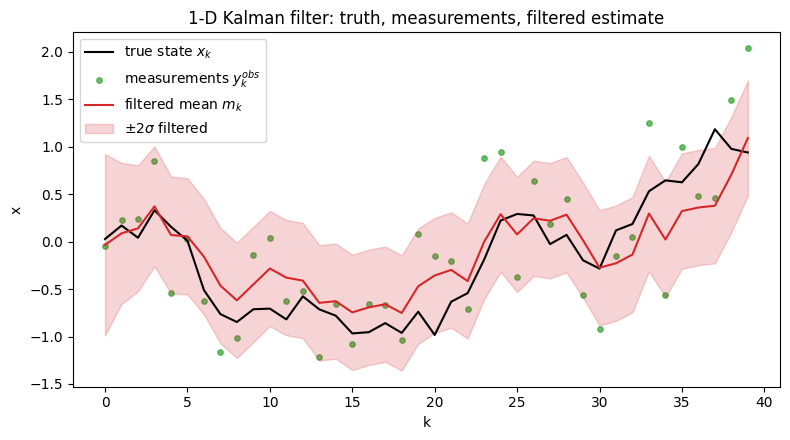

In [3]:
# ---- static summary plot: true state, measurements, filtered estimate with +-2 sigma band ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_true, label="true state $x_k$", color="k")
ax.scatter(range(N), y_obs, s=15, color="tab:green", label="measurements $y_k^{obs}$", alpha=0.7)
ax.plot(m_filt, label="filtered mean $m_k$", color="tab:red")
std_filt = np.sqrt(P_filt)
ax.fill_between(range(N), m_filt - 2*std_filt, m_filt + 2*std_filt,
                 color="tab:red", alpha=0.2, label="$\\pm 2\\sigma$ filtered")
ax.set_xlabel("k")
ax.set_ylabel("x")
ax.legend()
ax.set_title("1-D Kalman filter: truth, measurements, filtered estimate")
plt.tight_layout()
plt.show()


# Q. 2D-Position Estimation

## Part A

The state is $x_k = \begin{bmatrix}p_x(k)\\p_y(k)\\v_x(k)\\v_y(k)\end{bmatrix}$, evolving with sampling interval $\Delta t$ under constant-velocity kinematics perturbed by a small random acceleration (process noise) $w_{k-1}=\begin{bmatrix}w_x\\w_y\end{bmatrix}\sim\mathscr N(0,\Sigma_p)$, which we may think of as an unknown, approximately constant acceleration acting over the interval $[t_{k-1},t_k)$.

**Position update (kinematics with constant acceleration $w$ over $\Delta t$):**
$$
p_x(k) = p_x(k-1) + v_x(k-1)\,\Delta t + \tfrac12 w_x \,\Delta t^2,
$$
$$
p_y(k) = p_y(k-1) + v_y(k-1)\,\Delta t + \tfrac12 w_y \,\Delta t^2.
$$

**Velocity update:**
$$
v_x(k) = v_x(k-1) + w_x\,\Delta t,\qquad v_y(k) = v_y(k-1) + w_y\,\Delta t.
$$

Writing these four scalar equations in matrix form $x_k^- = A\,x^+_{k-1} + G\,w_{k-1}$:
$$
\underbrace{\begin{bmatrix}p_x(k)\\p_y(k)\\v_x(k)\\v_y(k)\end{bmatrix}}_{x_k^-}
=
\underbrace{\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}}_{A}
\underbrace{\begin{bmatrix}p_x(k-1)\\p_y(k-1)\\v_x(k-1)\\v_y(k-1)\end{bmatrix}}_{x^+_{k-1}}
+
\underbrace{\begin{bmatrix}
\tfrac12\Delta t^2 & 0\\
0 & \tfrac12\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}}_{G}
\underbrace{\begin{bmatrix}w_x\\w_y\end{bmatrix}}_{w_{k-1}},
$$
which is exactly the claimed $A$ and $G$.

**Measurement.** Only the position components are observed, contaminated by noise $z_k\sim\mathscr N(0,\Sigma_m)$:
$$
y_k = \begin{bmatrix}p_x^{\mathrm{meas}}(k)\\p_y^{\mathrm{meas}}(k)\end{bmatrix}
= \underbrace{\begin{bmatrix}1&0&0&0\\0&1&0&0\end{bmatrix}}_{H} x_k^- + z_k,
$$
i.e. $H$ simply selects the first two (position) components of the state, as claimed. $\blacksquare$

## Part B

Below we

1. simulate a 2-D constant-velocity (with small random accelerations) trajectory and corresponding noisy "GPS" position measurements,
2. implement the standard predict/update Kalman-filter recursion using the $A,G,H$ derived in Part A,
3. plot the true path, the noisy GPS fixes, and the filtered (smoothed) trajectory.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------------------------------------------------------------
# Model setup
# ---------------------------------------------------------------
dt = 1.0                      # time step (e.g. seconds)
N = 60                        # number of time steps

A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

G = np.array([[0.5*dt**2, 0],
              [0, 0.5*dt**2],
              [dt, 0],
              [0, dt]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

q_acc = 0.02                  # process (acceleration) noise variance per axis
Sigma_p = q_acc * np.eye(2)

r_gps = 4.0                   # GPS measurement noise variance per axis (e.g. metres^2)
Sigma_m = r_gps * np.eye(2)

# ---------------------------------------------------------------
# Simulate a true trajectory and noisy GPS measurements
# ---------------------------------------------------------------
x0_true = np.array([0.0, 0.0, 1.0, 0.5])   # start at origin, moving with v=(1, 0.5)

x_true = np.zeros((N, 4))
y_meas = np.zeros((N, 2))

x_prev = x0_true
for k in range(N):
    w = rng.multivariate_normal(np.zeros(2), Sigma_p)
    x_k = A @ x_prev + G @ w
    z = rng.multivariate_normal(np.zeros(2), Sigma_m)
    y_meas[k] = H @ x_k + z
    x_true[k] = x_k
    x_prev = x_k

# ---------------------------------------------------------------
# Kalman filter
# ---------------------------------------------------------------
def kalman_filter_gps(y_meas, A, G, H, Sigma_p, Sigma_m, m0, P0):
    '''Standard linear-Gaussian Kalman filter.

    Parameters
    ----------
    y_meas : (N, 2) array of noisy position measurements
    A, G, H : model matrices
    Sigma_p, Sigma_m : process / measurement noise covariances
    m0, P0 : prior mean (4,) and covariance (4,4) of the initial state

    Returns
    -------
    m_filt : (N, 4) filtered state means
    P_filt : (N, 4, 4) filtered state covariances
    '''
    N = y_meas.shape[0]
    n = A.shape[0]
    m_filt = np.zeros((N, n))
    P_filt = np.zeros((N, n, n))

    m_prev, P_prev = m0, P0
    I = np.eye(n)
    for k in range(N):
        # ---- predict ----
        m_minus = A @ m_prev
        P_minus = A @ P_prev @ A.T + G @ Sigma_p @ G.T

        # ---- update ----
        S = H @ P_minus @ H.T + Sigma_m
        K = P_minus @ H.T @ np.linalg.inv(S)
        v = y_meas[k] - H @ m_minus
        m_k = m_minus + K @ v
        P_k = (I - K @ H) @ P_minus

        m_filt[k] = m_k
        P_filt[k] = P_k
        m_prev, P_prev = m_k, P_k

    return m_filt, P_filt

m0 = np.array([0.0, 0.0, 0.0, 0.0])   # we don't know the initial velocity well
P0 = np.diag([5.0, 5.0, 4.0, 4.0])

m_filt, P_filt = kalman_filter_gps(y_meas, A, G, H, Sigma_p, Sigma_m, m0, P0)

rmse_meas = np.sqrt(np.mean(np.sum((y_meas - x_true[:, :2])**2, axis=1)))
rmse_filt = np.sqrt(np.mean(np.sum((m_filt[:, :2] - x_true[:, :2])**2, axis=1)))
print(f"RMSE of raw GPS measurements : {rmse_meas:.3f}")
print(f"RMSE of Kalman-filtered path : {rmse_filt:.3f}")


RMSE of raw GPS measurements : 2.683
RMSE of Kalman-filtered path : 1.415


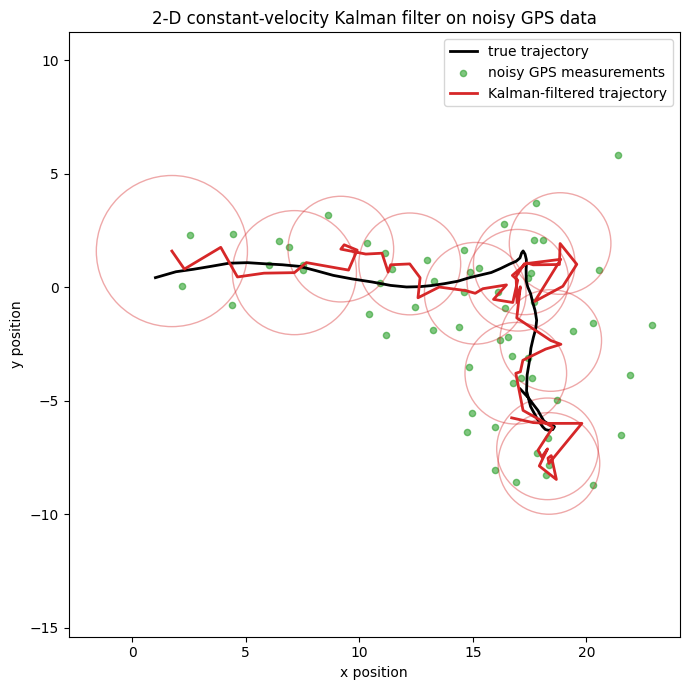

In [5]:
# ---------------------------------------------------------------
# Plot: true trajectory, noisy GPS fixes, filtered trajectory
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_true[:, 0], x_true[:, 1], 'k-', lw=2, label="true trajectory")
ax.scatter(y_meas[:, 0], y_meas[:, 1], s=20, color="tab:green", alpha=0.6, label="noisy GPS measurements")
ax.plot(m_filt[:, 0], m_filt[:, 1], color="tab:red", lw=2, label="Kalman-filtered trajectory")

# uncertainty ellipses every few steps
from matplotlib.patches import Ellipse
for k in range(0, N, 5):
    cov_pos = P_filt[k][:2, :2]
    eigvals, eigvecs = np.linalg.eigh(cov_pos)
    angle = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
    width, height = 2 * 2 * np.sqrt(np.maximum(eigvals, 0))   # 2-sigma ellipse
    ell = Ellipse(xy=m_filt[k, :2], width=width, height=height, angle=angle,
                  edgecolor="tab:red", facecolor="none", alpha=0.4, lw=1)
    ax.add_patch(ell)

ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.set_title("2-D constant-velocity Kalman filter on noisy GPS data")
ax.legend()
ax.axis("equal")
plt.tight_layout()
plt.show()


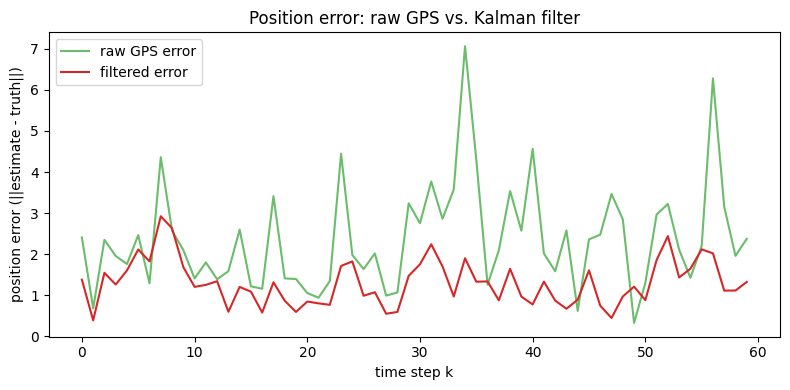

In [6]:
# ---------------------------------------------------------------
# Plot: position error over time (measurement vs filtered)
# ---------------------------------------------------------------
err_meas = np.linalg.norm(y_meas - x_true[:, :2], axis=1)
err_filt = np.linalg.norm(m_filt[:, :2] - x_true[:, :2], axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(err_meas, label="raw GPS error", color="tab:green", alpha=0.7)
ax.plot(err_filt, label="filtered error", color="tab:red")
ax.set_xlabel("time step k")
ax.set_ylabel("position error (||estimate - truth||)")
ax.set_title("Position error: raw GPS vs. Kalman filter")
ax.legend()
plt.tight_layout()
plt.show()
